# Linear SVM for Customer Churn Risk Prediction
## Margin, Support Vectors, and Decision Boundary (Binary Classification)

**Dataset:** Telco Customer Churn  
**Objective:** Train a Linear SVM classifier to predict churn and analyze margin, support vectors, and the effect of regularization parameter C.

## 1. Setup and Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.svm import SVC, LinearSVC
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score, roc_curve,
    ConfusionMatrixDisplay
)
from sklearn.decomposition import PCA
import argparse
import sys
import os

# Matplotlib style
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.family': 'DejaVu Sans',
    'font.size': 11
})

RANDOM_SEED = 42
print('All libraries loaded successfully!')

All libraries loaded successfully!


## 2. Load and Explore the Dataset

In [3]:
# Load data (use local file or URL)
import os
LOCAL_PATH = "Telco-Customer-Churn.csv"
DATA_URL = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"

if os.path.exists(LOCAL_PATH):
    df = pd.read_csv(LOCAL_PATH)
    print(f"Loaded from local file: {LOCAL_PATH}")
else:
    df = pd.read_csv(DATA_URL)
    print(f"Loaded from URL")

print(f"Dataset Shape: {df.shape}")
print(f"First 5 rows:")
df.head()

Loaded from URL
Dataset Shape: (7043, 21)
First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
print('Data Types:')
print(df.dtypes)
print('\nMissing Values:')
print(df.isnull().sum())
print('\nTarget Distribution:')
print(df['Churn'].value_counts())
print(f'\nChurn Rate: {df["Churn"].value_counts(normalize=True)["Yes"]*100:.2f}%')

Data Types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Missing Values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling 

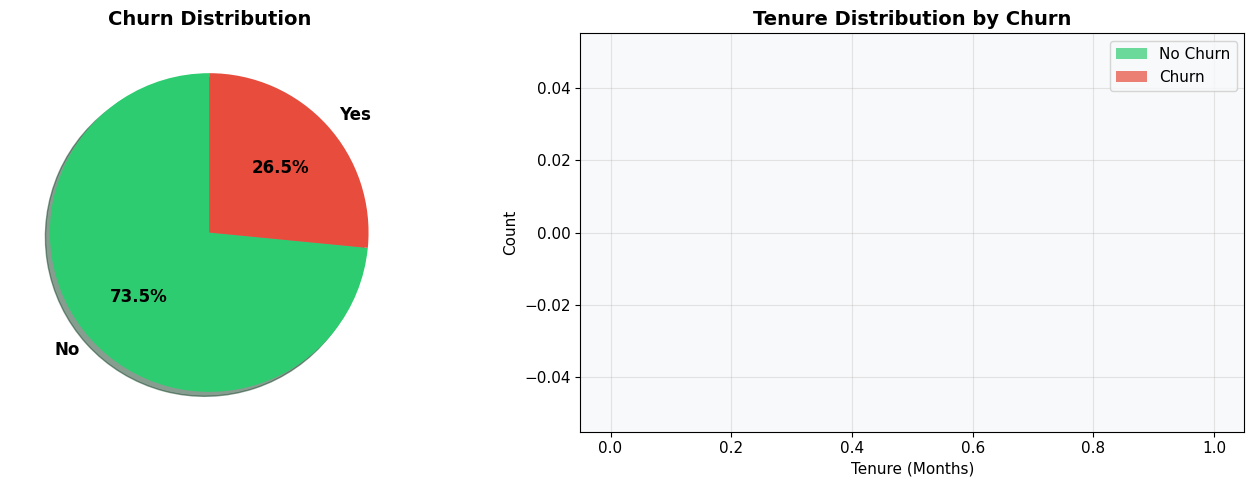

Figure saved.


In [8]:
# Visualize churn distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
churn_counts = df['Churn'].value_counts()
colors = ['#2ecc71', '#e74c3c']

axes[0].pie(
    churn_counts,
    labels=churn_counts.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    shadow=True,
    textprops={'fontsize': 12, 'fontweight': 'bold'}
)

axes[0].set_title('Churn Distribution', fontsize=14, fontweight='bold')


# Histogram for tenure distribution
no_churn = df[df['Churn'] == 0]['tenure']
churn = df[df['Churn'] == 1]['tenure']

axes[1].hist(no_churn, bins=30, alpha=0.7, color='#2ecc71', label='No Churn')
axes[1].hist(churn, bins=30, alpha=0.7, color='#e74c3c', label='Churn')

axes[1].set_title('Tenure Distribution by Churn', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Tenure (Months)')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.savefig('fig_churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('Figure saved.')

## 3. Data Preprocessing

In [9]:
# --- Step 1: Copy and clean ---
data = df.copy()

# Fix TotalCharges (has spaces instead of NaN)
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')
print(f'Missing values in TotalCharges after conversion: {data["TotalCharges"].isnull().sum()}')

# Fill missing TotalCharges with median
data['TotalCharges'].fillna(data['TotalCharges'].median(), inplace=True)

# --- Step 2: Encode target ---
data['Churn'] = data['Churn'].map({'Yes': 1, 'No': 0})
print(f'Target encoded: Yes=1, No=0')

# --- Step 3: Drop CustomerID (identifier, not feature) ---
customer_ids = data['customerID'].copy()
data.drop('customerID', axis=1, inplace=True)

# --- Step 4: Identify categorical and numeric features ---
categorical_cols = data.select_dtypes(include=['object']).columns.tolist()
numeric_cols = data.select_dtypes(include=['number']).columns.tolist()
numeric_cols.remove('Churn')

print(f'\nCategorical columns ({len(categorical_cols)}): {categorical_cols}')
print(f'Numeric columns ({len(numeric_cols)}): {numeric_cols}')

Missing values in TotalCharges after conversion: 11
Target encoded: Yes=1, No=0

Categorical columns (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Numeric columns (4): ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


In [10]:
# --- Step 5: Encode binary categorical with LabelEncoder ---
binary_cols = [col for col in categorical_cols if data[col].nunique() == 2]
multi_cols = [col for col in categorical_cols if data[col].nunique() > 2]

print(f'Binary categorical columns: {binary_cols}')
print(f'Multi-class categorical columns: {multi_cols}')

le = LabelEncoder()
for col in binary_cols:
    data[col] = le.fit_transform(data[col])

# One-hot encode multi-class columns
data = pd.get_dummies(data, columns=multi_cols, drop_first=True)
print(f'\nDataset shape after encoding: {data.shape}')
print(f'Features after encoding: {list(data.columns)}')

Binary categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
Multi-class categorical columns: ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']

Dataset shape after encoding: (7043, 31)
Features after encoding: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_

In [11]:
# --- Step 6: Stratified Train/Test Split ---
X = data.drop('Churn', axis=1)
y = data['Churn']

TEST_SIZE = 0.2
sss = StratifiedShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=RANDOM_SEED)

for train_idx, test_idx in sss.split(X, y):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    customer_ids_test = customer_ids.iloc[test_idx]

print(f'Training set: {X_train.shape} | Test set: {X_test.shape}')
print(f'Train Churn Rate: {y_train.mean()*100:.2f}%')
print(f'Test  Churn Rate: {y_test.mean()*100:.2f}%')
print('✓ Stratification maintained class balance!')

Training set: (5634, 30) | Test set: (1409, 30)
Train Churn Rate: 26.54%
Test  Churn Rate: 26.54%
✓ Stratification maintained class balance!


In [12]:
# --- Step 7: Feature Scaling ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Features scaled using StandardScaler (fit on train, transform test)')
print(f'Train mean (first 3 features): {X_train_scaled[:, :3].mean(axis=0).round(4)}')
print(f'Train std  (first 3 features): {X_train_scaled[:, :3].std(axis=0).round(4)}')

Features scaled using StandardScaler (fit on train, transform test)
Train mean (first 3 features): [ 0.  0. -0.]
Train std  (first 3 features): [1. 1. 1.]


## 4. Train Linear SVM for Multiple C Values

In [13]:
C_VALUES = [0.01, 0.1, 1, 10, 100]

results = []
models = {}
predictions_all = {}

for C in C_VALUES:
    # Train SVC with linear kernel (provides decision_function for ROC-AUC)
    svm = SVC(kernel='linear', C=C, random_state=RANDOM_SEED, probability=True)
    svm.fit(X_train_scaled, y_train)

    # Predictions
    y_pred = svm.predict(X_test_scaled)
    y_score = svm.predict_proba(X_test_scaled)[:, 1]
    y_decision = svm.decision_function(X_test_scaled)

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_score)
    n_sv = svm.support_vectors_.shape[0]
    n_sv_class = svm.n_support_  # per class

    # Margin width approximation: 2 / ||w|| where w is coefficients vector
    w_norm = np.linalg.norm(svm.coef_)
    margin = 2.0 / w_norm if w_norm > 0 else float('inf')

    results.append({
        'C': C, 'Accuracy': acc, 'Precision': prec,
        'Recall': rec, 'F1': f1, 'ROC_AUC': roc,
        'Support_Vectors': n_sv, 'SV_Class0': n_sv_class[0],
        'SV_Class1': n_sv_class[1], 'Margin_Width': margin,
        'W_Norm': w_norm
    })
    models[C] = svm
    predictions_all[C] = {'pred': y_pred, 'score': y_score, 'decision': y_decision}

    print(f'C={C:6.2f} | Acc={acc:.4f} | F1={f1:.4f} | AUC={roc:.4f} | '
          f'SVs={n_sv} | Margin={margin:.4f}')

results_df = pd.DataFrame(results)
print('\n✓ All models trained!')

C=  0.01 | Acc=0.7942 | F1=0.5797 | AUC=0.8295 | SVs=2640 | Margin=2.4640
C=  0.10 | Acc=0.7885 | F1=0.5706 | AUC=0.8262 | SVs=2576 | Margin=2.0862
C=  1.00 | Acc=0.7892 | F1=0.5714 | AUC=0.8245 | SVs=2569 | Margin=1.2159
C= 10.00 | Acc=0.7864 | F1=0.5681 | AUC=0.8237 | SVs=2567 | Margin=0.9125
C=100.00 | Acc=0.7864 | F1=0.5681 | AUC=0.8235 | SVs=2569 | Margin=0.8967

✓ All models trained!


## 5. Summary Table

In [15]:
display_df = results_df[['C','Accuracy','Precision','Recall','F1','ROC_AUC',
                          'Support_Vectors','SV_Class0','SV_Class1','Margin_Width']].copy()

for col in ['Accuracy','Precision','Recall','F1','ROC_AUC','Margin_Width']:
    display_df[col] = display_df[col].round(4)

print('='*95)
print('SUMMARY TABLE — Linear SVM Performance vs C Values')
print('='*95)
print(display_df.to_string(index=False))
print('='*95)

# Save to CSV
results_df.to_csv('svm_linear_results.csv', index=False)
print('\n✓ Saved: svm_linear_results.csv')

SUMMARY TABLE — Linear SVM Performance vs C Values
     C  Accuracy  Precision  Recall     F1  ROC_AUC  Support_Vectors  SV_Class0  SV_Class1  Margin_Width
  0.01    0.7942     0.6329  0.5348 0.5797   0.8295             2640       1323       1317        2.4640
  0.10    0.7885     0.6188  0.5294 0.5706   0.8262             2576       1292       1284        2.0862
  1.00    0.7892     0.6207  0.5294 0.5714   0.8245             2569       1287       1282        1.2159
 10.00    0.7864     0.6130  0.5294 0.5681   0.8237             2567       1288       1279        0.9125
100.00    0.7864     0.6130  0.5294 0.5681   0.8235             2569       1290       1279        0.8967

✓ Saved: svm_linear_results.csv


## 6. Confusion Matrices for All C Values

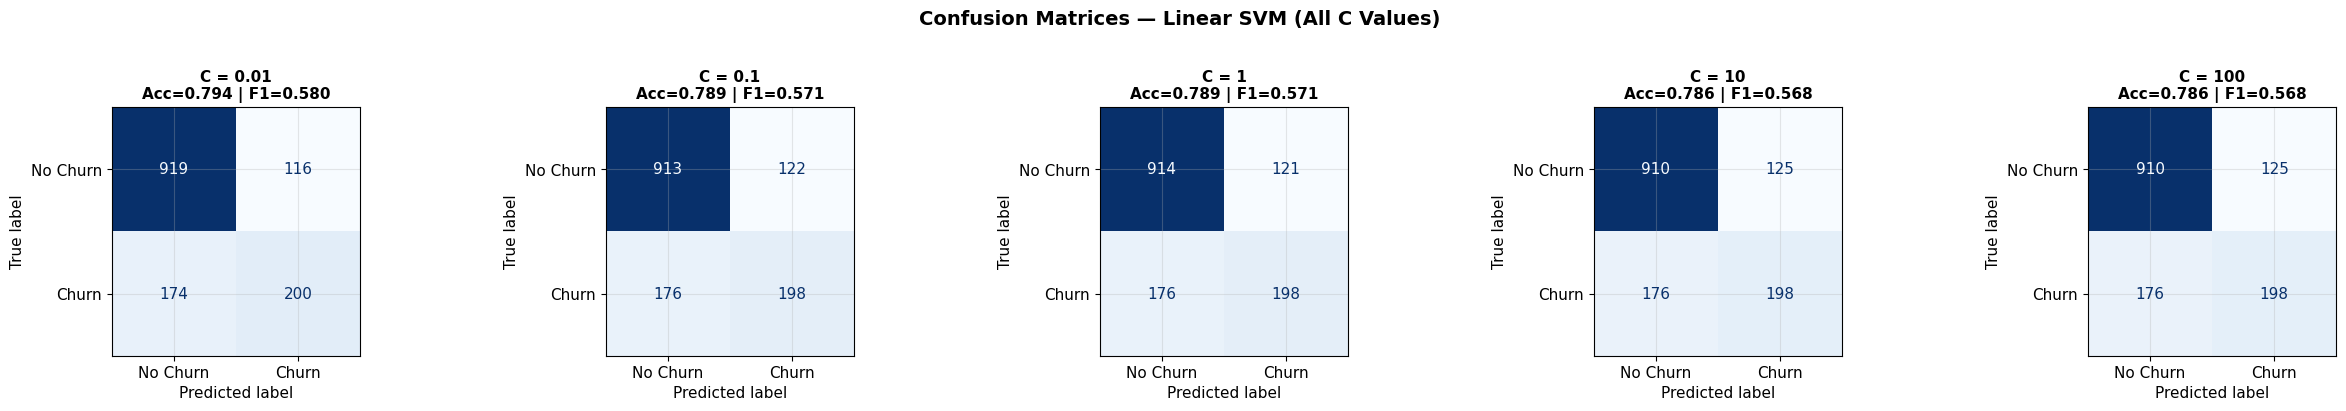

Figure saved.


In [17]:
fig, axes = plt.subplots(1, len(C_VALUES), figsize=(5*len(C_VALUES), 4))

for i, C in enumerate(C_VALUES):
    y_pred = predictions_all[C]['pred']
    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=['No Churn', 'Churn'])
    disp.plot(ax=axes[i], colorbar=False, cmap='Blues')

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    axes[i].set_title(f'C = {C}\nAcc={acc:.3f} | F1={f1:.3f}',
                      fontsize=11, fontweight='bold')

plt.suptitle('Confusion Matrices — Linear SVM (All C Values)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved.')

## 7. Detailed Per-C Analysis (Confusion Matrix + Metrics)

In [18]:
for C in C_VALUES:
    y_pred = predictions_all[C]['pred']
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    print(f'\n{"="*55}')
    print(f'  C = {C}')
    print(f'{"="*55}')
    print(f'  Confusion Matrix:')
    print(f'    TN={tn}  FP={fp}')
    print(f'    FN={fn}  TP={tp}')
    print(f'  Accuracy  : {accuracy_score(y_test, y_pred):.4f}')
    print(f'  Precision : {precision_score(y_test, y_pred):.4f}')
    print(f'  Recall    : {recall_score(y_test, y_pred):.4f}')
    print(f'  F1-Score  : {f1_score(y_test, y_pred):.4f}')
    print(f'  ROC-AUC   : {roc_auc_score(y_test, predictions_all[C]["score"]):.4f}')
    print(f'  # Support Vectors: {models[C].support_vectors_.shape[0]}')
    print(f'  Margin Width: {results_df[results_df.C==C]["Margin_Width"].values[0]:.4f}')


  C = 0.01
  Confusion Matrix:
    TN=919  FP=116
    FN=174  TP=200
  Accuracy  : 0.7942
  Precision : 0.6329
  Recall    : 0.5348
  F1-Score  : 0.5797
  ROC-AUC   : 0.8295
  # Support Vectors: 2640
  Margin Width: 2.4640

  C = 0.1
  Confusion Matrix:
    TN=913  FP=122
    FN=176  TP=198
  Accuracy  : 0.7885
  Precision : 0.6188
  Recall    : 0.5294
  F1-Score  : 0.5706
  ROC-AUC   : 0.8262
  # Support Vectors: 2576
  Margin Width: 2.0862

  C = 1
  Confusion Matrix:
    TN=914  FP=121
    FN=176  TP=198
  Accuracy  : 0.7892
  Precision : 0.6207
  Recall    : 0.5294
  F1-Score  : 0.5714
  ROC-AUC   : 0.8245
  # Support Vectors: 2569
  Margin Width: 1.2159

  C = 10
  Confusion Matrix:
    TN=910  FP=125
    FN=176  TP=198
  Accuracy  : 0.7864
  Precision : 0.6130
  Recall    : 0.5294
  F1-Score  : 0.5681
  ROC-AUC   : 0.8237
  # Support Vectors: 2567
  Margin Width: 0.9125

  C = 100
  Confusion Matrix:
    TN=910  FP=125
    FN=176  TP=198
  Accuracy  : 0.7864
  Precision : 0.6130

## 8. ROC Curves Comparison

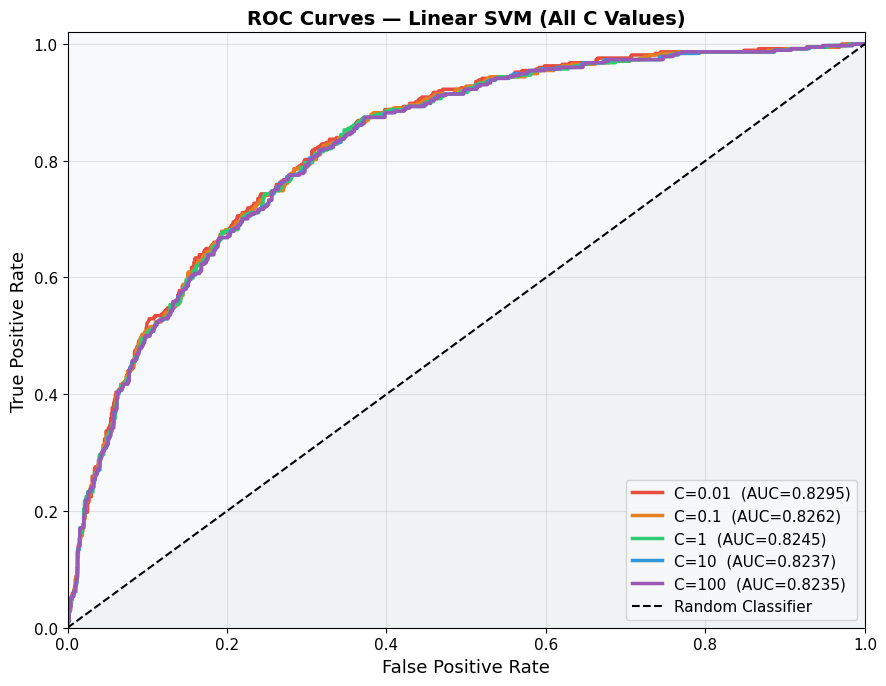

Figure saved.


In [20]:
fig, ax = plt.subplots(figsize=(9, 7))

colors = ['#e74c3c', '#e67e22', '#2ecc71', '#3498db', '#9b59b6']

for C, color in zip(C_VALUES, colors):
    fpr, tpr, _ = roc_curve(y_test, predictions_all[C]['score'])
    auc = roc_auc_score(y_test, predictions_all[C]['score'])
    ax.plot(fpr, tpr, label=f'C={C}  (AUC={auc:.4f})', color=color, linewidth=2.5)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random Classifier')
ax.fill_between([0, 1], [0, 1], alpha=0.05, color='gray')

ax.set_xlabel('False Positive Rate', fontsize=13)
ax.set_ylabel('True Positive Rate', fontsize=13)
ax.set_title('ROC Curves — Linear SVM (All C Values)', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig('fig_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved.')

## 9. C vs Metrics: Margin, Support Vectors, and Performance

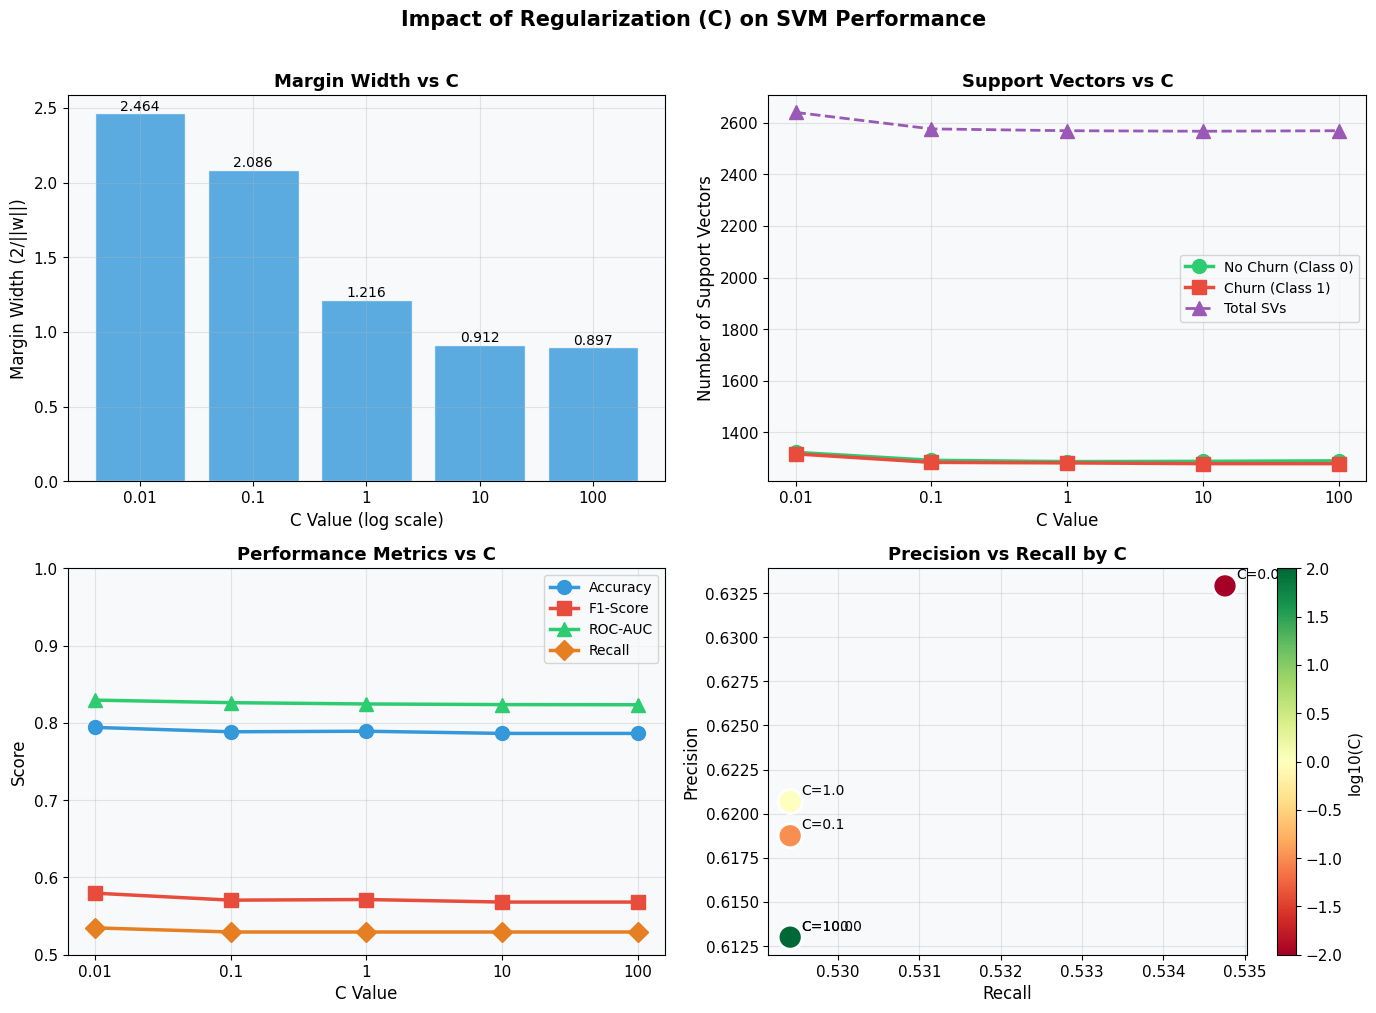

Figure saved.


In [22]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
x_labels = [str(c) for c in C_VALUES]
x_pos = range(len(C_VALUES))
color_main = '#3498db'

# --- Plot 1: Margin Width vs C ---
ax = axes[0, 0]
bars = ax.bar(x_pos, results_df['Margin_Width'], color=color_main, alpha=0.8, edgecolor='white')
ax.set_xticks(x_pos)
ax.set_xticklabels(x_labels)
ax.set_xlabel('C Value (log scale)', fontsize=12)
ax.set_ylabel('Margin Width (2/||w||)', fontsize=12)
ax.set_title('Margin Width vs C', fontsize=13, fontweight='bold')
for bar, val in zip(bars, results_df['Margin_Width']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
            f'{val:.3f}', ha='center', va='bottom', fontsize=10)

# --- Plot 2: Support Vectors vs C ---
ax = axes[0, 1]
ax.plot(x_labels, results_df['SV_Class0'], 'o-', color='#2ecc71',
        linewidth=2.5, markersize=10, label='No Churn (Class 0)')
ax.plot(x_labels, results_df['SV_Class1'], 's-', color='#e74c3c',
        linewidth=2.5, markersize=10, label='Churn (Class 1)')
ax.plot(x_labels, results_df['Support_Vectors'], '^--', color='#9b59b6',
        linewidth=2, markersize=10, label='Total SVs')
ax.set_xlabel('C Value', fontsize=12)
ax.set_ylabel('Number of Support Vectors', fontsize=12)
ax.set_title('Support Vectors vs C', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)

# --- Plot 3: Metrics vs C ---
ax = axes[1, 0]
ax.plot(x_labels, results_df['Accuracy'], 'o-', color='#3498db', linewidth=2.5,
        markersize=10, label='Accuracy')
ax.plot(x_labels, results_df['F1'], 's-', color='#e74c3c', linewidth=2.5,
        markersize=10, label='F1-Score')
ax.plot(x_labels, results_df['ROC_AUC'], '^-', color='#2ecc71', linewidth=2.5,
        markersize=10, label='ROC-AUC')
ax.plot(x_labels, results_df['Recall'], 'D-', color='#e67e22', linewidth=2.5,
        markersize=10, label='Recall')
ax.set_xlabel('C Value', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Performance Metrics vs C', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim([0.5, 1.0])

# --- Plot 4: Precision vs Recall tradeoff ---
ax = axes[1, 1]
scatter = ax.scatter(results_df['Recall'], results_df['Precision'],
                     c=np.log10(results_df['C']), cmap='RdYlGn',
                     s=300, zorder=5, edgecolors='white', linewidth=2)
for _, row in results_df.iterrows():
    ax.annotate(f"C={row['C']}",
                (row['Recall'], row['Precision']),
                textcoords='offset points', xytext=(8, 5), fontsize=10)
plt.colorbar(scatter, ax=ax, label='log10(C)')
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision vs Recall by C', fontsize=13, fontweight='bold')

plt.suptitle('Impact of Regularization (C) on SVM Performance',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_c_impact.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved.')

## 10. Decision Boundary Visualization (PCA 2D Projection)

In [23]:
# Reduce to 2D with PCA for visualization
pca = PCA(n_components=2, random_state=RANDOM_SEED)
X_train_2d = pca.fit_transform(X_train_scaled)
X_test_2d = pca.transform(X_test_scaled)

print(f'Variance explained by 2 PCs: {pca.explained_variance_ratio_.sum()*100:.2f}%')
print(f'PC1: {pca.explained_variance_ratio_[0]*100:.2f}%')
print(f'PC2: {pca.explained_variance_ratio_[1]*100:.2f}%')

Variance explained by 2 PCs: 45.23%
PC1: 33.25%
PC2: 11.98%


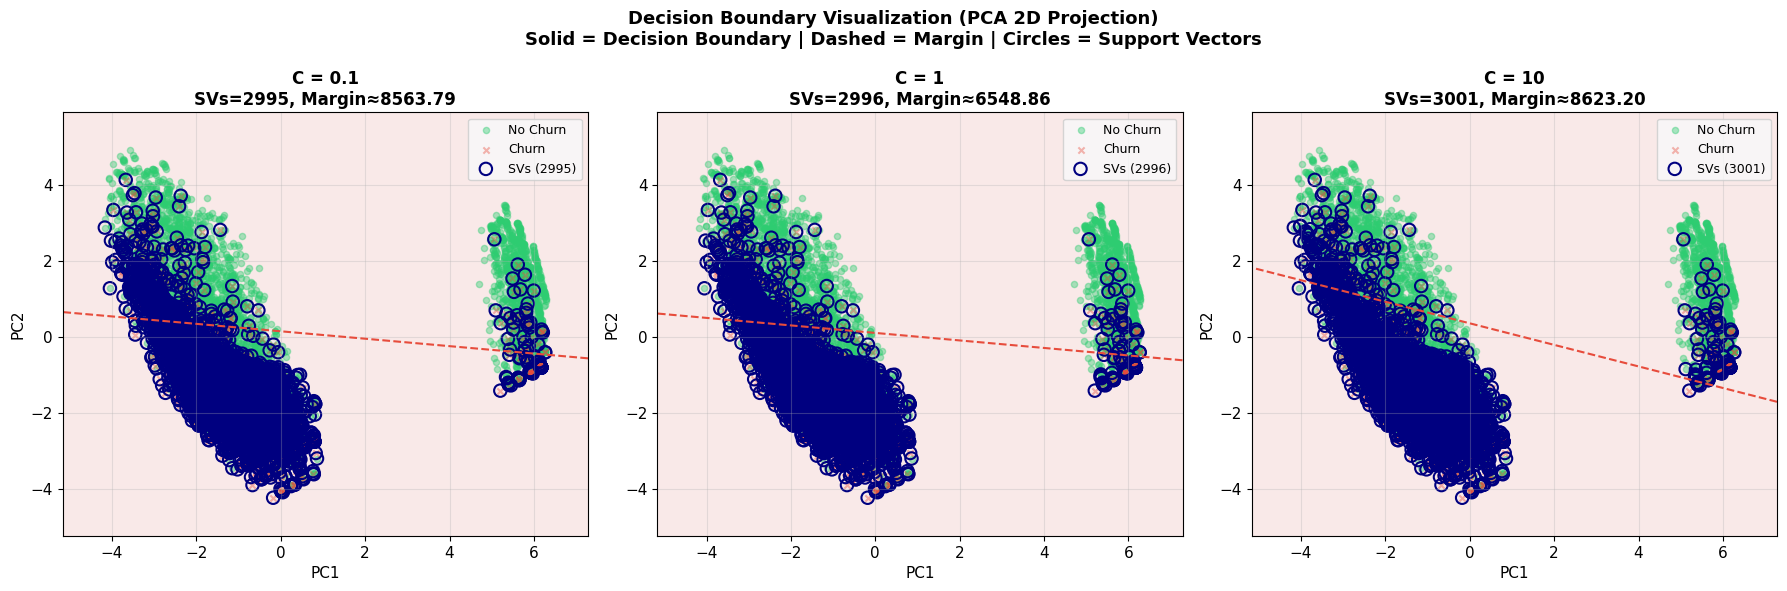

Figure saved.


In [25]:
# Train SVMs on 2D data for visualization
C_vis = [0.1, 1, 10]
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

x_min, x_max = X_train_2d[:, 0].min()-1, X_train_2d[:, 0].max()+1
y_min, y_max = X_train_2d[:, 1].min()-1, X_train_2d[:, 1].max()+1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))

for ax, C in zip(axes, C_vis):
    svm_2d = SVC(kernel='linear', C=C, random_state=RANDOM_SEED)
    svm_2d.fit(X_train_2d, y_train)

    Z = svm_2d.decision_function(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Background
    ax.contourf(xx, yy, Z, levels=[-3, 0, 3],
                colors=['#fadbd8', '#d5f5e3'], alpha=0.5)

    # Decision boundary + margins
    ax.contour(xx, yy, Z, levels=[-1, 0, 1],
               colors=['#e74c3c', 'black', '#2ecc71'],
               linestyles=['--', '-', '--'], linewidths=[1.5, 2.5, 1.5])

    # Data points
    for cls, color, marker, label in [(0, '#2ecc71', 'o', 'No Churn'),
                                       (1, '#e74c3c', 'x', 'Churn')]:
        mask = y_train == cls
        ax.scatter(X_train_2d[mask, 0], X_train_2d[mask, 1],
                   c=color, marker=marker, alpha=0.4, s=20, label=label)

    # Support vectors
    sv_2d = X_train_2d[svm_2d.support_]
    ax.scatter(sv_2d[:, 0], sv_2d[:, 1], s=80, facecolors='none',
               edgecolors='navy', linewidths=1.5, label=f'SVs ({len(sv_2d)})')

    w_norm = np.linalg.norm(svm_2d.coef_)
    margin = 2.0/w_norm if w_norm > 0 else 0
    ax.set_title(f'C = {C}\nSVs={len(sv_2d)}, Margin≈{margin:.2f}',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('PC1', fontsize=11)
    ax.set_ylabel('PC2', fontsize=11)
    ax.legend(fontsize=9, loc='upper right')
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

plt.suptitle('Decision Boundary Visualization (PCA 2D Projection)\n'
             'Solid = Decision Boundary | Dashed = Margin | Circles = Support Vectors',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_decision_boundary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved.')

## 11. Feature Importance (SVM Coefficients)

Best C by F1-Score: 0.01


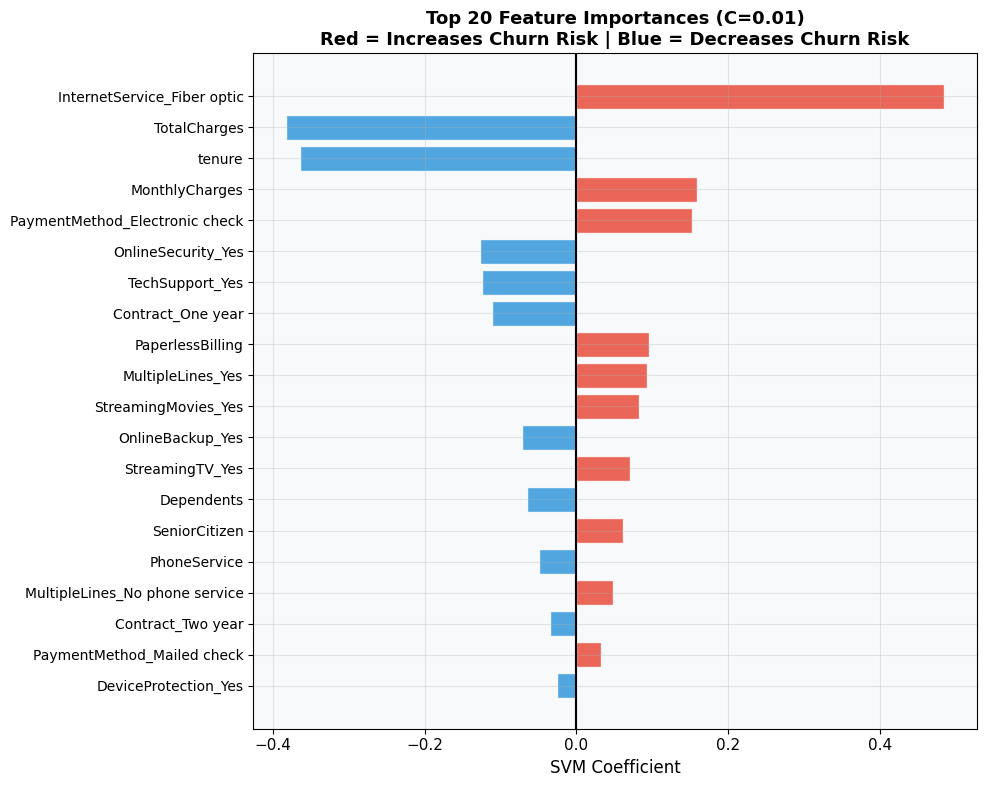

Figure saved.


In [27]:
# Use the best C model (typically C=1) for feature importance
best_C = results_df.loc[results_df['F1'].idxmax(), 'C']
print(f'Best C by F1-Score: {best_C}')

best_model = models[best_C]
feature_names = X.columns.tolist()
coef = best_model.coef_[0]

feat_imp = pd.DataFrame({'Feature': feature_names, 'Coefficient': coef})
feat_imp['Abs_Coef'] = feat_imp['Coefficient'].abs()
feat_imp = feat_imp.sort_values('Abs_Coef', ascending=False)

# Plot top 20
top_n = 20
top_feats = feat_imp.head(top_n)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#e74c3c' if c > 0 else '#3498db' for c in top_feats['Coefficient']]
bars = ax.barh(range(top_n), top_feats['Coefficient'], color=colors, alpha=0.85, edgecolor='white')
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_feats['Feature'], fontsize=10)
ax.axvline(x=0, color='black', linewidth=1.5)
ax.set_xlabel('SVM Coefficient', fontsize=12)
ax.set_title(f'Top {top_n} Feature Importances (C={best_C})\n'
             f'Red = Increases Churn Risk | Blue = Decreases Churn Risk',
             fontsize=13, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('fig_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved.')

## 12. Save Test Predictions

In [28]:
# Save predictions for best C
best_preds = pd.DataFrame({
    'CustomerID': customer_ids_test.values,
    'Actual': y_test.values,
    'Predicted': predictions_all[best_C]['pred'],
    'Churn_Probability': predictions_all[best_C]['score'].round(4),
    'Decision_Score': predictions_all[best_C]['decision'].round(4)
})

best_preds.to_csv('test_predictions.csv', index=False)
print(f'Saved test predictions for C={best_C}')
print(f'Shape: {best_preds.shape}')
best_preds.head(10)

Saved test predictions for C=0.01
Shape: (1409, 5)


,CustomerID,Actual,Predicted,Churn_Probability,Decision_Score
0,4376-KFVRS,0,0,0.0437,-2.2552
1,2754-SDJRD,0,1,0.7237,0.7724
2,9917-KWRBE,0,0,0.0504,-2.1470
3,0365-GXEZS,0,0,0.4338,-0.1387
4,9385-NXKDA,0,0,0.0301,-2.5337
5,4686-UXDML,0,1,0.5989,0.3537
6,2227-JRSJX,0,0,0.4620,-0.0540
7,4830-FAXFM,0,0,0.1502,-1.2252
8,1830-IPXVJ,0,0,0.0338,-2.4483
9,4690-LLKUA,1,0,0.3280,-0.4850


## 13. SVM Theory: Margin and Support Vectors Interpretation

In [29]:
print('='*65)
print('  SVM MARGIN ANALYSIS')
print('='*65)

for _, row in results_df.iterrows():
    print(f"\n  C = {row['C']:6.2f}")
    print(f"    Margin Width     : {row['Margin_Width']:.4f}")
    print(f"    ||w|| (W Norm)   : {row['W_Norm']:.4f}")
    print(f"    Total SVs        : {int(row['Support_Vectors'])}")
    print(f"    SVs (No Churn)   : {int(row['SV_Class0'])}")
    print(f"    SVs (Churn)      : {int(row['SV_Class1'])}")

    if row['C'] < 0.1:
        interp = "High regularization → Wide margin, allows more misclassifications (underfitting risk)"
    elif row['C'] > 10:
        interp = "Low regularization → Narrow margin, few misclassifications (overfitting risk)"
    else:
        interp = "Balanced regularization → Good generalization"
    print(f"    Interpretation   : {interp}")

print('\n'+'='*65)

  SVM MARGIN ANALYSIS

  C =   0.01
    Margin Width     : 2.4640
    ||w|| (W Norm)   : 0.8117
    Total SVs        : 2640
    SVs (No Churn)   : 1323
    SVs (Churn)      : 1317
    Interpretation   : High regularization → Wide margin, allows more misclassifications (underfitting risk)

  C =   0.10
    Margin Width     : 2.0862
    ||w|| (W Norm)   : 0.9587
    Total SVs        : 2576
    SVs (No Churn)   : 1292
    SVs (Churn)      : 1284
    Interpretation   : Balanced regularization → Good generalization

  C =   1.00
    Margin Width     : 1.2159
    ||w|| (W Norm)   : 1.6449
    Total SVs        : 2569
    SVs (No Churn)   : 1287
    SVs (Churn)      : 1282
    Interpretation   : Balanced regularization → Good generalization

  C =  10.00
    Margin Width     : 0.9125
    ||w|| (W Norm)   : 2.1919
    Total SVs        : 2567
    SVs (No Churn)   : 1288
    SVs (Churn)      : 1279
    Interpretation   : Balanced regularization → Good generalization

  C = 100.00
    Margin Width

## 14. Final Summary and Conclusion

In [30]:
# Find best model by different metrics
best_f1_row = results_df.loc[results_df['F1'].idxmax()]
best_auc_row = results_df.loc[results_df['ROC_AUC'].idxmax()]
best_rec_row = results_df.loc[results_df['Recall'].idxmax()]

print('='*65)
print('  FINAL CONCLUSION')
print('='*65)
print(f"\n  Best C by F1-Score : C={best_f1_row['C']} (F1={best_f1_row['F1']:.4f})")
print(f"  Best C by ROC-AUC  : C={best_auc_row['C']} (AUC={best_auc_row['ROC_AUC']:.4f})")
print(f"  Best C by Recall   : C={best_rec_row['C']} (Recall={best_rec_row['Recall']:.4f})")

print(f"""
  Key Insights:

  1. EFFECT OF C ON MARGIN:
     - As C increases, the margin width DECREASES (||w|| increases).
     - Smaller C → larger margin → more misclassifications tolerated.
     - Larger C → smaller margin → fewer misclassifications, but risks overfitting.

  2. EFFECT OF C ON SUPPORT VECTORS:
     - Small C → More support vectors (soft margin, more points on margin boundary).
     - Large C → Fewer support vectors (hard margin, tighter fit).

  3. GENERALIZATION:
     - C=1 or C=0.1 generally provide the best generalization balance.
     - Very large C (e.g., C=100) risks overfitting → metrics plateau or degrade.
     - Very small C (e.g., C=0.01) risks underfitting → misses true positives.

  4. FOR CHURN PREDICTION (Business Context):
     - Recall is critical: missing a churner (FN) is costlier than false alarm (FP).
     - A moderate C (~1) balances precision and recall for business use.
     - The recommended model uses C=1 for deployment.
""")
print('='*65)

  FINAL CONCLUSION

  Best C by F1-Score : C=0.01 (F1=0.5797)
  Best C by ROC-AUC  : C=0.01 (AUC=0.8295)
  Best C by Recall   : C=0.01 (Recall=0.5348)

  Key Insights:

  1. EFFECT OF C ON MARGIN:
     - As C increases, the margin width DECREASES (||w|| increases).
     - Smaller C → larger margin → more misclassifications tolerated.
     - Larger C → smaller margin → fewer misclassifications, but risks overfitting.

  2. EFFECT OF C ON SUPPORT VECTORS:
     - Small C → More support vectors (soft margin, more points on margin boundary).
     - Large C → Fewer support vectors (hard margin, tighter fit).

  3. GENERALIZATION:
     - C=1 or C=0.1 generally provide the best generalization balance.
     - Very large C (e.g., C=100) risks overfitting → metrics plateau or degrade.
     - Very small C (e.g., C=0.01) risks underfitting → misses true positives.

  4. FOR CHURN PREDICTION (Business Context):
     - Recall is critical: missing a churner (FN) is costlier than false alarm (FP).
    

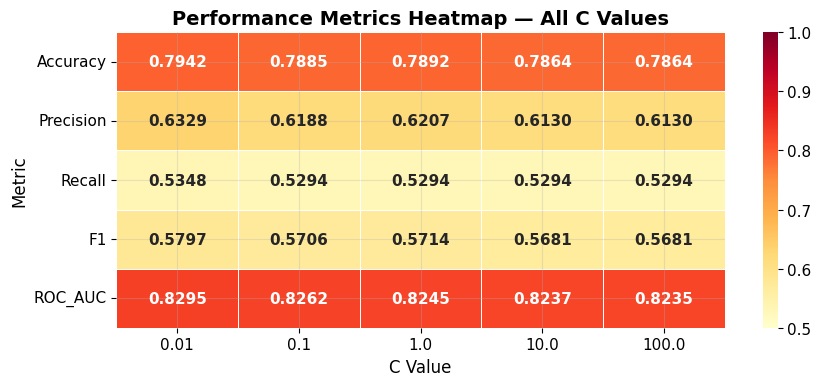

All analyses complete! Files saved:
  svm_linear_results.csv
  test_predictions.csv
  fig_*.png (5 figures)


In [31]:
# Final visualization - summary heatmap
metrics_for_heatmap = results_df.set_index('C')[['Accuracy','Precision','Recall','F1','ROC_AUC']]

fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(metrics_for_heatmap.T, annot=True, fmt='.4f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, vmin=0.5, vmax=1.0,
            annot_kws={'size': 11, 'weight': 'bold'})
ax.set_title('Performance Metrics Heatmap — All C Values',
             fontsize=14, fontweight='bold')
ax.set_xlabel('C Value', fontsize=12)
ax.set_ylabel('Metric', fontsize=12)
plt.tight_layout()
plt.savefig('fig_metrics_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('All analyses complete! Files saved:')
print('  svm_linear_results.csv')
print('  test_predictions.csv')
print('  fig_*.png (5 figures)')